In [1]:
# Install dependencies
!pip install -q transformers torch torchvision pillow opencv-python numpy tqdm accelerate

In [2]:
import torch
import gc
import os
from transformers import DPTForDepthEstimation, DPTImageProcessor
from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation
from PIL import Image
import numpy as np
from tqdm import tqdm
import cv2

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA L4
VRAM: 23.66 GB


## Configure Paths

**Option 1: Upload images directly**
```python
from google.colab import files
uploaded = files.upload()
```

**Option 2: Use Google Drive (recommended)**

In [3]:
# Mount Google Drive (optional)
from google.colab import drive
drive.mount('/content/drive')

# ===== UPDATE THESE PATHS =====
INPUT_DIR = r"/content/drive/MyDrive/5190 S26 Final Project/Dataset/MODELIMG/Resized and cleaned"
OUTPUT_BASE = r"/content/drive/MyDrive/5190 S26 Final Project/Dataset/MODELIMG"

# Create output directories
DEPTH_DIR = os.path.join(OUTPUT_BASE, "DepthMap")
SEG_DIR = os.path.join(OUTPUT_BASE, "SegmentationMap")

os.makedirs(DEPTH_DIR, exist_ok=True)
os.makedirs(SEG_DIR, exist_ok=True)

print(f"Input:  {INPUT_DIR}")
print(f"Depth:  {DEPTH_DIR}")
print(f"Seg:    {SEG_DIR}")

Mounted at /content/drive
Input:  /content/drive/MyDrive/5190 S26 Final Project/Dataset/MODELIMG/Resized and cleaned
Depth:  /content/drive/MyDrive/5190 S26 Final Project/Dataset/MODELIMG/DepthMap
Seg:    /content/drive/MyDrive/5190 S26 Final Project/Dataset/MODELIMG/SegmentationMap


## Load Models (Optimized for L4 GPU)

Loading models once at the start - DO NOT reload in the loop!

In [4]:
print("Loading Depth Estimation Model...")

# Use DPT-Large for quality (L4 has enough VRAM)
depth_model = DPTForDepthEstimation.from_pretrained(
    "Intel/dpt-large",
    torch_dtype=torch.float16  # FP16 for speed on L4
).to(device)
depth_processor = DPTImageProcessor.from_pretrained("Intel/dpt-large")
depth_model.eval()

print("✓ Depth model loaded (FP16)")

# Clear cache
torch.cuda.empty_cache()
gc.collect()

Loading Depth Estimation Model...


config.json:   0%|          | 0.00/942 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


preprocessor_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

✓ Depth model loaded (FP16)


561

In [5]:
print("Loading Segmentation Model...")

# Use OneFormer (better than DETR for segmentation)
seg_processor = OneFormerProcessor.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_tiny"
)
seg_model = OneFormerForUniversalSegmentation.from_pretrained(
    "shi-labs/oneformer_ade20k_swin_tiny",
    torch_dtype=torch.float16
).to(device)
seg_model.eval()

print("✓ Segmentation model loaded (FP16)")

# Clear cache
torch.cuda.empty_cache()
gc.collect()

Loading Segmentation Model...


preprocessor_config.json: 0.00B [00:00, ?B/s]

The image processor of type `OneFormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ade20k_panoptic.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/203M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/610 [00:00<?, ?it/s]

✓ Segmentation model loaded (FP16)


160

## Processing Functions

In [6]:
@torch.no_grad()  # Disable gradient computation for speed
def process_depth_optimized(image_path, output_path):
    """Generate depth map - optimized for L4 GPU"""
    try:
        # Load image
        image = Image.open(image_path).convert("RGB")

        # Preprocess
        inputs = depth_processor(images=image, return_tensors="pt")
        inputs = {k: v.to(device, dtype=torch.float16) for k, v in inputs.items()}

        # Inference
        outputs = depth_model(**inputs)
        predicted_depth = outputs.predicted_depth

        # Resize to 512x512 (match your preprocessed images)
        prediction = torch.nn.functional.interpolate(
            predicted_depth.unsqueeze(1),
            size=(512, 512),
            mode="bicubic",
            align_corners=False,
        ).squeeze()

        # Convert to numpy and normalize
        output = prediction.cpu().float().numpy()
        output = (output - output.min()) / (output.max() - output.min())
        output = (output * 255).astype(np.uint8)

        # Save
        Image.fromarray(output).save(output_path, quality=95)

        # Cleanup
        del inputs, outputs, predicted_depth, prediction, image, output

        return True
    except Exception as e:
        print(f"Error processing {os.path.basename(image_path)}: {e}")
        return False


@torch.no_grad()
def process_segmentation_optimized(image_path, output_path):
    """Generate segmentation map - optimized for L4 GPU"""
    try:
        # Load and resize image
        image = Image.open(image_path).convert("RGB")
        image = image.resize((512, 512), Image.Resampling.LANCZOS)

        # Preprocess
        inputs = seg_processor(images=image, task_inputs=["semantic"], return_tensors="pt")
        inputs = {k: v.to(device, dtype=torch.float16) if isinstance(v, torch.Tensor) else v
                  for k, v in inputs.items()}

        # Inference
        outputs = seg_model(**inputs)

        # Post-process
        predicted_semantic_map = seg_processor.post_process_semantic_segmentation(
            outputs,
            target_sizes=[(512, 512)]
        )[0]

        # Convert to numpy and normalize to 0-255
        seg_map = predicted_semantic_map.cpu().numpy().astype(np.uint8)

        # Normalize to use full 0-255 range for better visualization
        if seg_map.max() > 0:
            seg_map = (seg_map / seg_map.max() * 255).astype(np.uint8)

        # Save
        Image.fromarray(seg_map, mode='L').save(output_path, quality=95)

        # Cleanup
        del inputs, outputs, predicted_semantic_map, image, seg_map

        return True
    except Exception as e:
        print(f"Error processing {os.path.basename(image_path)}: {e}")
        return False


print("✓ Processing functions defined")

✓ Processing functions defined


## Process All Images

**This will take ~5-10 minutes on L4 GPU for 202 images**

In [7]:
# Get list of images
image_files = [f for f in os.listdir(INPUT_DIR)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Found {len(image_files)} images to process\n")

# Track statistics
stats = {
    'depth': {'success': 0, 'failed': 0},
    'seg': {'success': 0, 'failed': 0}
}

# Process in batches with progress bar
print("Processing Depth Maps...")
for filename in tqdm(image_files, desc="Depth"):
    input_path = os.path.join(INPUT_DIR, filename)
    output_path = os.path.join(DEPTH_DIR, filename)

    if process_depth_optimized(input_path, output_path):
        stats['depth']['success'] += 1
    else:
        stats['depth']['failed'] += 1

    # Clear cache every 50 images
    if (stats['depth']['success'] + stats['depth']['failed']) % 50 == 0:
        torch.cuda.empty_cache()
        gc.collect()

print(f"\n✓ Depth maps complete: {stats['depth']['success']}/{len(image_files)} successful\n")

# Clear memory before segmentation
torch.cuda.empty_cache()
gc.collect()

print("Processing Segmentation Maps...")
for filename in tqdm(image_files, desc="Segmentation"):
    input_path = os.path.join(INPUT_DIR, filename)
    output_path = os.path.join(SEG_DIR, filename)

    if process_segmentation_optimized(input_path, output_path):
        stats['seg']['success'] += 1
    else:
        stats['seg']['failed'] += 1

    # Clear cache every 50 images
    if (stats['seg']['success'] + stats['seg']['failed']) % 50 == 0:
        torch.cuda.empty_cache()
        gc.collect()

print(f"\n✓ Segmentation maps complete: {stats['seg']['success']}/{len(image_files)} successful")

# Final summary
print("\n" + "="*80)
print("PROCESSING COMPLETE")
print("="*80)
print(f"Depth Maps:        {stats['depth']['success']:3d} success, {stats['depth']['failed']:3d} failed")
print(f"Segmentation Maps: {stats['seg']['success']:3d} success, {stats['seg']['failed']:3d} failed")
print(f"\nOutput saved to: {OUTPUT_BASE}")

Found 380 images to process

Processing Depth Maps...



Depth: 100%|██████████| 380/380 [00:58<00:00,  6.49it/s]



✓ Depth maps complete: 380/380 successful

Processing Segmentation Maps...


Segmentation:   0%|          | 0/380 [00:00<?, ?it/s]/tmp/ipykernel_3360/2281675751.py:71: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(seg_map, mode='L').save(output_path, quality=95)
Segmentation: 100%|██████████| 380/380 [00:37<00:00, 10.09it/s]


✓ Segmentation maps complete: 380/380 successful

PROCESSING COMPLETE
Depth Maps:        380 success,   0 failed
Segmentation Maps: 380 success,   0 failed

Output saved to: /content/drive/MyDrive/5190 S26 Final Project/Dataset/MODELIMG


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

## Verify Results

Display sample outputs to verify quality

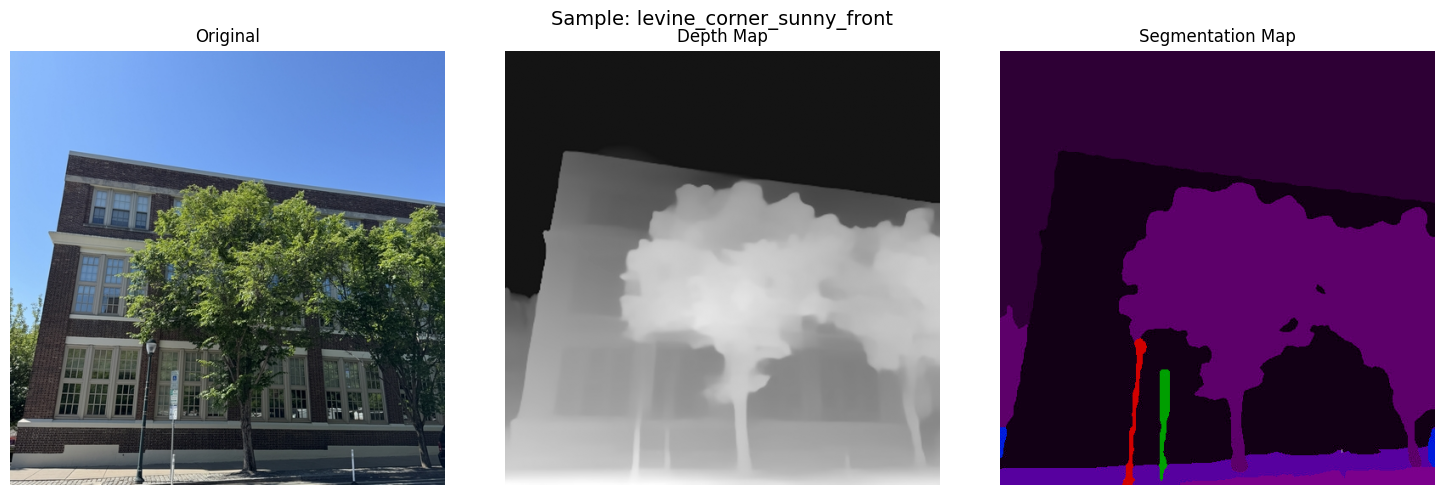

✓ Verification complete


In [9]:
import matplotlib.pyplot as plt

# Get a sample image
sample_file = image_files[0]
sample_name = os.path.splitext(sample_file)[0]

# Load images
original = Image.open(os.path.join(INPUT_DIR, sample_file))
depth = Image.open(os.path.join(DEPTH_DIR, sample_file))
seg = Image.open(os.path.join(SEG_DIR, sample_file))

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Sample: {sample_name}', fontsize=14)

axes[0].imshow(original)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(depth, cmap='gray')
axes[1].set_title('Depth Map')
axes[1].axis('off')

axes[2].imshow(seg, cmap='nipy_spectral')
axes[2].set_title('Segmentation Map')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Verification complete")

## Download Results (Optional)

If you want to download the maps to your local machine

In [ ]:
# Create ZIP files for easy download
import shutil

print("Creating ZIP archives...")

# Zip depth maps
shutil.make_archive('/content/DepthMaps', 'zip', DEPTH_DIR)
print("✓ DepthMaps.zip created")

# Zip segmentation maps
shutil.make_archive('/content/SegmentationMaps', 'zip', SEG_DIR)
print("✓ SegmentationMaps.zip created")

# Download
from google.colab import files
files.download('/content/DepthMaps.zip')
files.download('/content/SegmentationMaps.zip')

print("\n✓ Download started - check your browser downloads")